# Proyecto de Análisis de Datos

Este proyecto tiene como objetivo analizar si existen diferencias significativas en el rendimiento académico de los estudiantes de grado décimo según la especialidad técnica cursada.

La base de datos contiene las calificaciones de 197 estudiantes en diferentes asignaturas académicas, así como la especialidad técnica a la que pertenece cada estudiante.

Se descargan las debidas librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, levene, kruskal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

#Se realiza la carga del archivo "Notas 10.xlsx".

In [3]:
import pandas as pd
from google.colab import files
import io

print("Please upload your Excel file (e.g., Notas 10.xlsx).")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_excel(io.BytesIO(uploaded[fn]))
  print("File loaded successfully. Here are the first 5 rows:")
  print(df.head())

Please upload your Excel file (e.g., Notas 10.xlsx).


Saving Notas 10.xlsx to Notas 10.xlsx
User uploaded file "Notas 10.xlsx" with length 63617 bytes
File loaded successfully. Here are the first 5 rows:
   Column1                         Column2  LENG   TRIG  BIOLO  FISI  QUIM   \
0        1       AREVALO MESA DILAN ALEXIS    2.0   2.1    3.3   3.0    3.6   
1        2   BURGOS RUBIO ANGELA VALENTINA    2.0   2.3    2.3   2.1    2.0   
2        3     CAJAMARCA PRADO LAURA SOFIA    3.3   2.6    3.8   3.0    2.5   
3        4   CAMPOS BOLIVAR KEVIN SANTIAGO    3.0   2.3    2.1   1.4    2.0   
4        5  CASTAÑEDA ERASO NICOLE ALEJAND    4.2   2.7    3.9   3.0    2.8   

   FILO   CPOL   INGL   ...  EYV   INFO   Electricidad   Electronica  \
0    3.7    3.0    3.7  ...   3.7    3.3              1            0   
1    1.7    2.7    1.7  ...   3.8    2.2              1            0   
2    3.8    4.4    4.0  ...   4.0    3.4              1            0   
3    3.1    3.5    2.8  ...   3.6    2.4              1            0   
4    3.8    3.5

#Calcular el promedio académico general de cada estudiante.

In [4]:
materias = [
    "LENG ",
    "TRIG",
    "BIOLO",
    "FISI",
    "QUIM ",
    "FILO ",
    "CPOL ",
    "INGL ",
    "EFIS ",
    "REL ",
    "EYV ",
    "INFO "
]

df["Promedio"] = df[materias].mean(axis=1)

df[["Column2", "Promedio"]].head()

,Column2,Promedio
0,AREVALO MESA DILAN ALEXIS,3.216667
1,BURGOS RUBIO ANGELA VALENTINA,2.375000
2,CAJAMARCA PRADO LAURA SOFIA,3.550000
3,CAMPOS BOLIVAR KEVIN SANTIAGO,2.683333
4,CASTAÑEDA ERASO NICOLE ALEJAND,3.525000


In [5]:
# Mostrar el estudiante con menor promedio

indice_minimo = df["Promedio"].idxmin()

print(df.loc[indice_minimo])

Column1                                                 100
Column2                      BOHORQUEZ APONTE ELKIN SANTIAG
LENG                                                    0.1
TRIG                                                    0.3
BIOLO                                                   0.4
FISI                                                    1.4
QUIM                                                    0.0
FILO                                                    1.8
CPOL                                                    0.0
INGL                                                    1.0
EFIS                                                    2.6
REL                                                     0.0
EYV                                                     0.0
INFO                                                    0.0
Electricidad                                              0
Electronica                                               0
Electromecanica                         

### Eliminación del valor atípico

Durante la etapa de preparación y exploración de los datos se identificó un estudiante con un rendimiento académico significativamente inferior al resto de la población analizada.

La presencia de este caso extremo generaba una distorsión importante en los análisis de agrupamiento (K-Means), provocando la formación de un cluster compuesto por un único estudiante. Este comportamiento reducía la capacidad del modelo para identificar patrones representativos dentro de la población estudiantil y afectaba la interpretación de los resultados.


In [6]:
# Eliminar únicamente el estudiante con menor promedio

indice_minimo = df["Promedio"].idxmin()

df = df.drop(indice_minimo).copy()

print("Registros restantes:", len(df))

Registros restantes: 196


# Creación de la variable Técnica

Las especialidades técnicas se encuentran codificadas mediante variables binarias (One-Hot Encoding).

Se construye una variable categórica denominada Tecnica.

In [7]:
tecnicas = [
    "Electricidad ",
    "Electronica",
    "Electromecanica",
    "Diseño corte y confeccion",
    "Soldadura ",
    "Ebanisteria",
    "Diseño arquitectonico",
    "Mecanica"
]

df["Tecnica"] = df[tecnicas].idxmax(axis=1)

df[["Column2", "Tecnica"]].head()

,Column2,Tecnica
0,AREVALO MESA DILAN ALEXIS,Electricidad
1,BURGOS RUBIO ANGELA VALENTINA,Electricidad
2,CAJAMARCA PRADO LAURA SOFIA,Electricidad
3,CAMPOS BOLIVAR KEVIN SANTIAGO,Electricidad
4,CASTAÑEDA ERASO NICOLE ALEJAND,Electricidad


# Estadística descriptiva por técnica

Se calculan medidas descriptivas para comparar el rendimiento académico entre especialidades.

In [8]:
estadisticas = df.groupby("Tecnica")["Promedio"].agg(
    ["count", "mean", "std", "min", "max"]
)

estadisticas

,count,mean,std,min,max
Tecnica,,,,,
Diseño arquitectonico,42,3.625198,0.381031,2.525000,4.391667
Diseño corte y confeccion,26,3.648397,0.311484,2.575000,4.150000
Ebanisteria,18,3.497685,0.409266,2.666667,3.991667
Electricidad,32,3.461458,0.331607,2.375000,4.133333
Electromecanica,17,3.588725,0.324143,3.041667,4.175000
Electronica,33,3.490657,0.467256,2.516667,4.325000
Mecanica,13,3.428205,0.165431,3.166667,3.716667
Soldadura,15,3.585556,0.309192,3.058333,4.075000


# Visualización de datos

Se utiliza un diagrama de cajas para comparar la distribución de los promedios académicos entre técnicas.

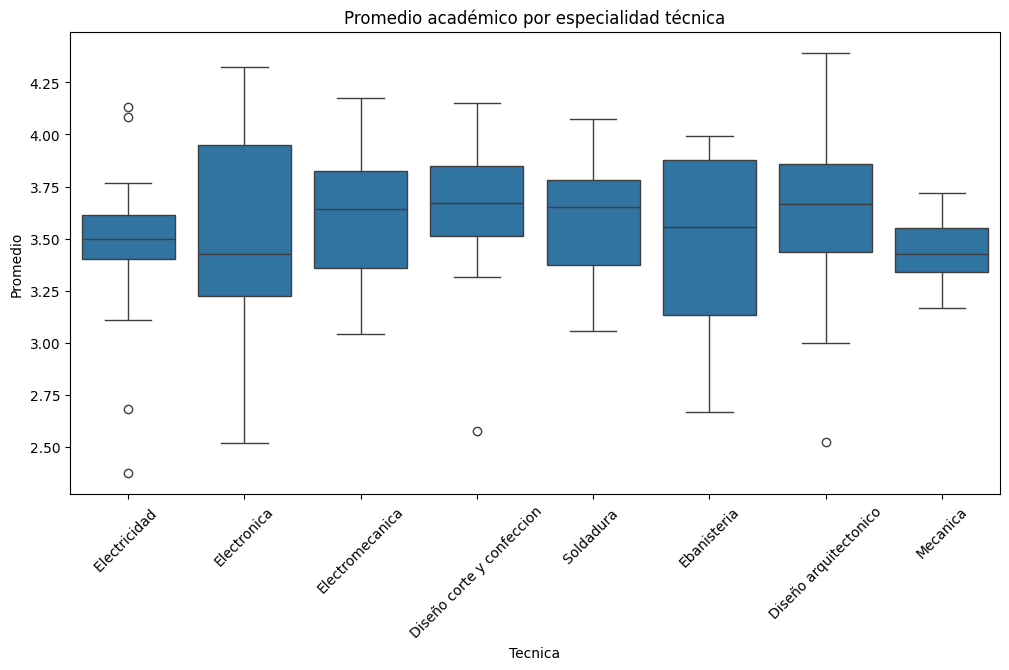

In [9]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Tecnica",
    y="Promedio"
)

plt.xticks(rotation=45)

plt.title("Promedio académico por especialidad técnica")

plt.show()

# Prueba de normalidad

Se aplica la prueba de Shapiro-Wilk sobre la variable Promedio.

In [10]:
stat, p = shapiro(df["Promedio"])

print("Estadístico:", stat)
print("Valor p:", p)

Estadístico: 0.9852903041933341
Valor p: 0.03869074772371255


# Homogeneidad de varianzas

Se aplica la prueba de Levene para verificar igualdad de varianzas entre grupos.

In [11]:
grupos = [
    grupo["Promedio"].values
    for _, grupo in df.groupby("Tecnica")
]

stat, p = levene(*grupos)

print("Estadístico:", stat)
print("Valor p:", p)

Estadístico: 2.3729882189613716
Valor p: 0.023981282373011677


#Prueba ANOVA
Para analizar si existen diferencias significativas en el Promedio General entre las distintas técnicas evaluadas, se utiliza un análisis de varianza (ANOVA de una vía). Este método es apropiado cuando se desea comparar las medias de más de dos grupos independientes, permitiendo determinar si al menos uno de ellos presenta diferencias estadísticamente significativas respecto a los demás.

El ANOVA parte de las siguientes hipótesis:

H0 (hipótesis nula): Todas las técnicas presentan la misma media en el Promedio General.
H1 (hipótesis alternativa): Al menos una técnica presenta una media diferente.

Antes de su aplicación, se asume que los datos cumplen con condiciones de normalidad y homogeneidad de varianzas, verificadas previamente mediante las pruebas de Shapiro-Wilk y Levene.

In [12]:
from scipy.stats import f_oneway

In [13]:
df.columns = df.columns.str.strip()

grupos = df.groupby('Tecnica')['Promedio'].apply(list)

grupos

,Promedio
Tecnica,
Diseño arquitectonico,"[3.691666666666667, 4.358333333333333, 3.74166..."
Diseño corte y confeccion,"[3.4583333333333326, 3.508333333333334, 2.575,..."
Ebanisteria,"[3.033333333333333, 2.6666666666666665, 3.1083..."
Electricidad,"[3.216666666666667, 2.3749999999999996, 3.5500..."
Electromecanica,"[3.691666666666667, 3.5083333333333333, 3.8833..."
Electronica,"[2.516666666666667, 3.3249999999999997, 4.1999..."
Mecanica,"[3.1666666666666665, 3.716666666666667, 3.3750..."
Soldadura,"[3.866666666666666, 3.525000000000001, 3.64999..."


In [14]:
stat, p = f_oneway(*grupos)

print("Estadístico F:", stat)
print("Valor p:", p)

if p < 0.05:
    print("👉 Se rechaza H0: hay diferencias significativas entre técnicas")
else:
    print("👉 No se rechaza H0: no hay diferencias significativas")

Estadístico F: 1.2283956179630788
Valor p: 0.2890675757898737
👉 No se rechaza H0: no hay diferencias significativas


In [16]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# TABLA MODELO ANOVA

modelo = smf.ols('Promedio ~ C(Tecnica)', data=df).fit()

anova_table = sm.stats.anova_lm(modelo, typ=2)

print("\nTABLA ANOVA")
print(anova_table)


TABLA ANOVA
               sum_sq     df         F    PR(>F)
C(Tecnica)   1.142029    7.0  1.228396  0.289068
Residual    24.968856  188.0       NaN       NaN


# Prueba de Kruskal-Wallis

Debido a que los supuestos del ANOVA no se cumplen completamente y no se rechaza H0, se utiliza una prueba no paramétrica para comparar las especialidades técnicas.

In [17]:
H, p = kruskal(*grupos)

print("Estadístico H:", H)
print("Valor p:", p)

Estadístico H: 10.632240628547487
Valor p: 0.1554843650875424


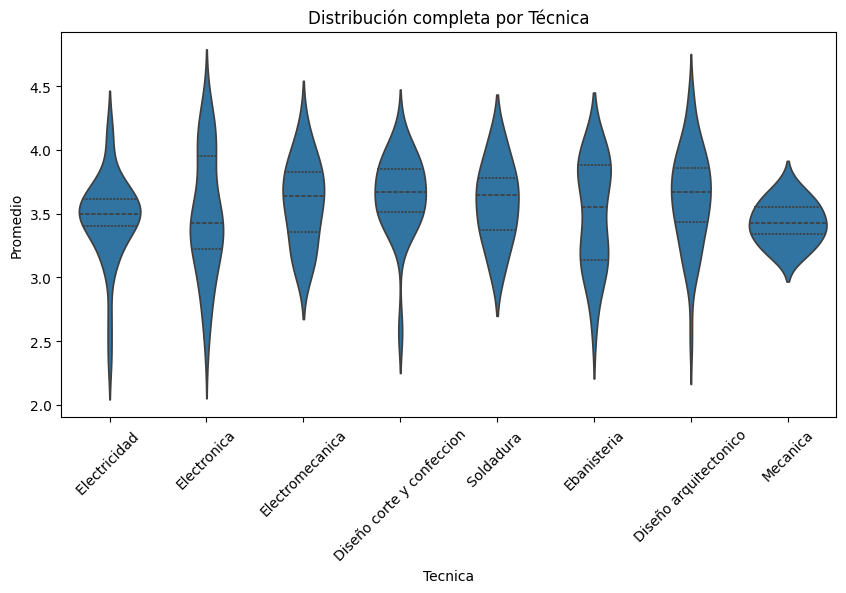

In [22]:
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x="Tecnica",
    y="Promedio",
    inner="quartile"
)

plt.xticks(rotation=45)
plt.title("Distribución completa por Técnica")
plt.show()

Dado que el valor p es mayor a 0.05, no se rechaza la hipótesis nula. Esto indica que no existen diferencias estadísticamente significativas entre las técnicas evaluadas en relación con el Promedio General.

En otras palabras, los resultados sugieren que el comportamiento de las técnicas es similar desde el punto de vista estadístico.

# Regresión Lineal

En esta sección se construye un modelo de regresión lineal múltiple para evaluar si la especialidad técnica cursada por los estudiantes tiene capacidad explicativa sobre su rendimiento académico.

Las variables independientes corresponden a las especialidades técnicas codificadas mediante One-Hot Encoding, mientras que la variable dependiente es el promedio académico general.

A partir del modelo se obtienen:

- Los coeficientes asociados a cada especialidad técnica.
- El intercepto del modelo.
- El coeficiente de determinación (R²).

El valor de R² permite cuantificar qué porcentaje de la variabilidad observada en el rendimiento académico puede ser explicado por la especialidad técnica cursada por los estudiantes.

In [ ]:
from sklearn.linear_model import LinearRegression

X_reg = df[
    [
        "Electricidad",
        "Electronica",
        "Electromecanica",
        "Diseño corte y confeccion",
        "Soldadura",
        "Ebanisteria",
        "Diseño arquitectonico"
    ]
]

y_reg = df["Promedio"]

modelo_reg = LinearRegression()

modelo_reg.fit(X_reg, y_reg)

coeficientes = pd.DataFrame(
    {
        "Variable": X_reg.columns,
        "Coeficiente": modelo_reg.coef_
    }
)

print("COEFICIENTES")
print(coeficientes.round(4))

print("\nIntercepto:")
print(round(modelo_reg.intercept_, 4))

r2 = modelo_reg.score(X_reg, y_reg)

print("\nR²:")
print(round(r2, 4))

print(
    f"\nLa especialidad técnica explica aproximadamente "
    f"{r2*100:.2f}% de la variabilidad observada en el rendimiento académico."
)

COEFICIENTES
                    Variable  Coeficiente
0               Electricidad       0.0333
1                Electronica       0.0625
2            Electromecanica       0.1605
3  Diseño corte y confeccion       0.2202
4                  Soldadura       0.1574
5                Ebanisteria       0.0695
6      Diseño arquitectonico       0.1970

Intercepto:
3.4282

R²:
0.0437

La especialidad técnica explica aproximadamente 4.37% de la variabilidad observada en el rendimiento académico.


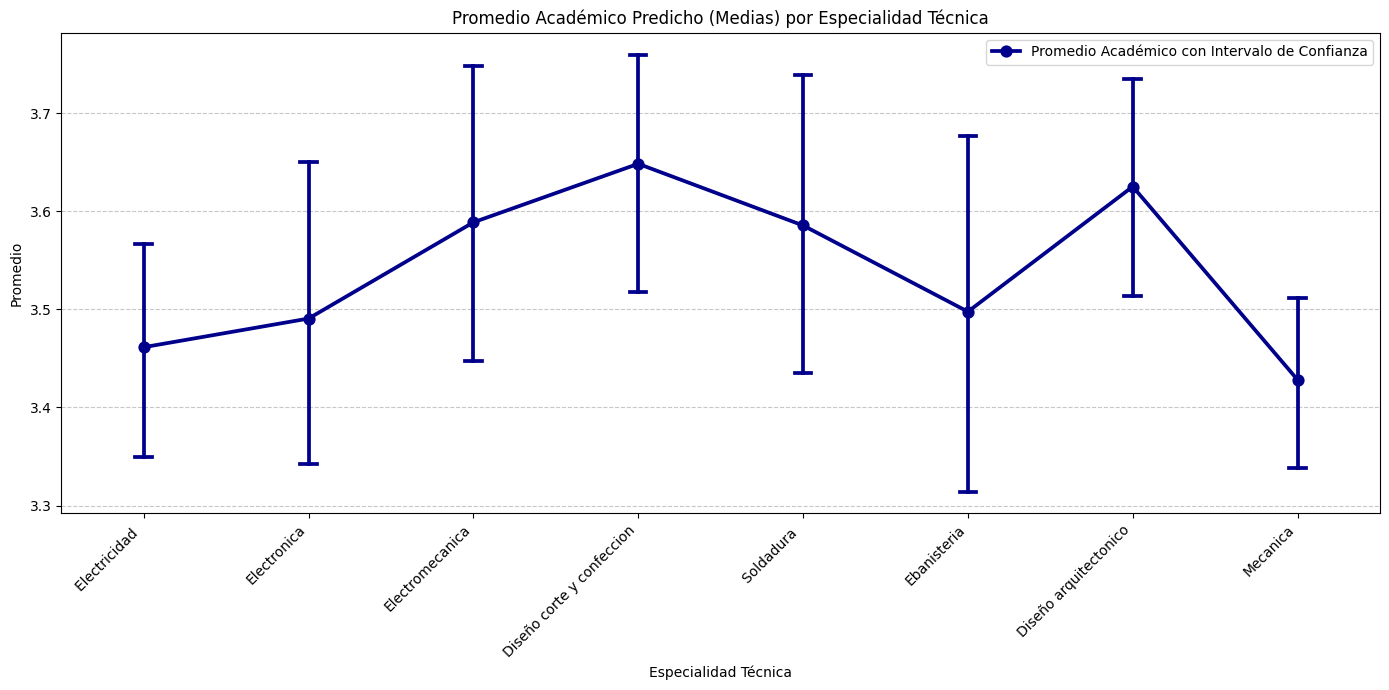

In [25]:
plt.figure(figsize=(14, 7))

sns.pointplot(
    data=df,
    x='Tecnica',
    y='Promedio',
    errorbar=('ci', 95), # Show 95% confidence interval
    capsize=0.1, # Width of the caps on the error bars
    color='darkblue',
    marker='o',
    linestyles='-',
    label='Promedio Académico con Intervalo de Confianza'
)

plt.xticks(rotation=45, ha='right')
plt.title('Promedio Académico Predicho (Medias) por Especialidad Técnica')
plt.ylabel('Promedio')
plt.xlabel('Especialidad Técnica')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Los resultados del modelo de regresión lineal indican que la especialidad técnica cursada por los estudiantes posee una capacidad explicativa limitada sobre el rendimiento académico general.

El coeficiente de determinación obtenido fue:

```text
R² = 0.0437
```

lo que significa que las especialidades técnicas explican aproximadamente el 4.37% de la variabilidad observada en los promedios académicos de los estudiantes. En consecuencia, más del 95% de la variabilidad del rendimiento académico está asociada a otros factores no incluidos en el modelo.

# Clusterización de Estudiantes

Además de los análisis estadísticos tradicionales, se implementa una técnica de aprendizaje no supervisado denominada **clusterización** con el fin de identificar grupos de estudiantes que presenten patrones académicos similares.

A diferencia de las pruebas estadísticas anteriores, que evalúan si existen diferencias significativas entre las especialidades técnicas, la clusterización permite explorar la estructura interna de los datos sin utilizar etiquetas o categorías predefinidas.

Para este propósito se utiliza el algoritmo **K-Means**, el cual agrupa estudiantes de acuerdo con la similitud de sus calificaciones en las diferentes asignaturas académicas.


In [ ]:
# CLUSTERIZACIÓN MEDIANTE K-MEANS

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap.umap_ as umap

# Selección de variables académicas

X_cluster = df[[materia.strip() for materia in materias]]

# Estandarización de variables

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)

## Reducción de Dimensionalidad mediante PCA

Antes de aplicar el algoritmo de clusterización, se realizó un proceso de reducción de dimensionalidad utilizando el método de Análisis de Componentes Principales (PCA).

La base de datos contiene múltiples asignaturas académicas que presentan cierto grado de correlación entre sí.
El objetivo del PCA es transformar las variables originales en un conjunto reducido de componentes principales que concentren la mayor cantidad posible de información. De esta manera, se simplifica la estructura de los datos conservando la mayor parte de la variabilidad presente en las calificaciones de los estudiantes.



In [ ]:
# REDUCCIÓN DE DIMENSIONALIDAD CON PCA

pca_modelo = PCA(
    n_components=0.90
)

X_pca = pca_modelo.fit_transform(
    X_scaled
)

print(
    "Número de componentes PCA:",
    X_pca.shape[1]
)

print(
    "Varianza explicada:",
    round(
        pca_modelo.explained_variance_ratio_.sum()*100,
        2
    ),
    "%"
)

Número de componentes PCA: 9
Varianza explicada: 91.64 %


## Evaluación del Número de Clusters

Antes de construir el modelo final de K-Means, es necesario determinar cuántos grupos representan mejor la estructura de los datos. Para ello se utiliza el **Silhouette Score**, una métrica que evalúa qué tan similares son los estudiantes dentro de un mismo cluster y qué tan diferentes son respecto a los demás grupos. Se prueban distintos valores de \(K\) y se selecciona aquel que produce la mejor calidad de agrupamiento.

In [ ]:
# EVALUACIÓN DEL NÚMERO DE CLUSTERS

print("\nEvaluación mediante Silhouette Score")

for k_test in range(2,11):

    modelo = KMeans(
        n_clusters=k_test,
        random_state=42,
        n_init=20
    )

    etiquetas = modelo.fit_predict(
        X_pca
    )

    sil = silhouette_score(
        X_pca,
        etiquetas
    )

    print(
        f"K = {k_test} -> Silhouette = {sil:.4f}"
    )


Evaluación mediante Silhouette Score
K = 2 -> Silhouette = 0.2331
K = 3 -> Silhouette = 0.1932
K = 4 -> Silhouette = 0.1789
K = 5 -> Silhouette = 0.1401
K = 6 -> Silhouette = 0.1448
K = 7 -> Silhouette = 0.1353
K = 8 -> Silhouette = 0.1489
K = 9 -> Silhouette = 0.1351
K = 10 -> Silhouette = 0.1404


## Validación del Modelo de Clusterización

Una vez seleccionado el número óptimo de clusters mediante el análisis del Silhouette Score, se construye el modelo final de K-Means. Posteriormente, se calcula nuevamente el índice de Silhouette para evaluar la calidad de la segmentación obtenida y se analiza el tamaño de cada cluster con el fin de verificar que los grupos identificados sean consistentes y representativos de la población estudiantil.

In [ ]:
# VALIDACIÓN DEL MODELO

modelo_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=20
)
df["Cluster"] = modelo_final.fit_predict(X_pca)

silhouette = silhouette_score(
    X_pca,
    df["Cluster"]
)

print("\nSilhouette Final:")
print(round(silhouette,4))

print("\nTamaño de los Clusters")

print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)


Silhouette Final:
0.2331

Tamaño de los Clusters
Cluster
0    106
1     90
Name: count, dtype: int64


## Análisis de los Centroides

Los centroides representan el perfil promedio de cada cluster en las distintas asignaturas académicas. Su análisis permite identificar las características que diferencian a los grupos encontrados por K-Means y comprender qué nivel de desempeño académico presenta cada cluster. Para facilitar la interpretación, los valores se transforman nuevamente a la escala original de las calificaciones.

In [ ]:
# CENTROIDES

centroides = pd.DataFrame(
    scaler.inverse_transform(
        pca_modelo.inverse_transform(
            modelo_final.cluster_centers_
        )
    ),
    columns=materias
)

print("\nCentroides de los Clusters")

print(
    centroides.round(2)
)


Centroides de los Clusters
   LENG   TRIG  BIOLO  FISI  QUIM   FILO   CPOL   INGL   EFIS   REL   EYV   \
0   3.03  2.85   3.31  2.97   2.95   3.42   3.46   3.37   3.17  3.96  3.71   
1   3.60  3.77   3.91  3.58   3.69   3.99   3.91   4.13   3.80  4.29  4.08   

   INFO   
0   3.21  
1   3.54  


## Relación entre Especialidad Técnica y Clusters

Con el fin de analizar si los grupos identificados por K-Means están asociados a alguna especialidad técnica en particular, se construye una tabla de contingencia entre la técnica cursada y el cluster asignado a cada estudiante. Esta comparación permite evaluar si los patrones de rendimiento académico encontrados dependen de la especialidad técnica o si, por el contrario, se distribuyen de manera transversal entre todas las técnicas.

In [ ]:
# TABLA TÉCNICA VS CLUSTER
print("\nTabla Técnica vs Cluster")

print(
    pd.crosstab(
        df["Tecnica"],
        df["Cluster"]
    )
)



Tabla Técnica vs Cluster
Cluster                     0   1
Tecnica                          
Diseño arquitectonico      18  24
Diseño corte y confeccion  11  15
Ebanisteria                 9   9
Electricidad               21  11
Electromecanica             8   9
Electronica                22  11
Mecanica                   10   3
Soldadura                   7   8


## Comparación del Rendimiento Académico entre Clusters

Con el propósito de analizar las diferencias en el desempeño académico de los grupos identificados, se construye un diagrama de caja (Boxplot) utilizando el promedio académico de cada estudiante. Esta visualización permite comparar la distribución de los promedios, identificar diferencias en la tendencia central y evaluar la dispersión de las calificaciones dentro de cada cluster.

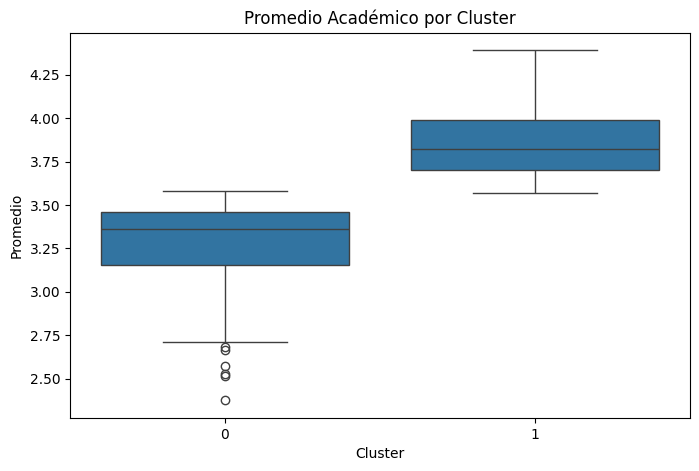

In [ ]:
# BOXPLOT POR CLUSTER
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Cluster",
    y="Promedio"
)

plt.title(
    "Promedio Académico por Cluster"
)

plt.show()

## Visualización de los Clusters mediante PCA

Para facilitar la interpretación de los resultados, se realiza una visualización bidimensional utilizando los dos primeros componentes principales obtenidos mediante PCA. Esta representación permite observar gráficamente la distribución de los estudiantes y evaluar el nivel de separación entre los clusters identificados por K-Means, conservando la mayor cantidad posible de información de las variables académicas originales.

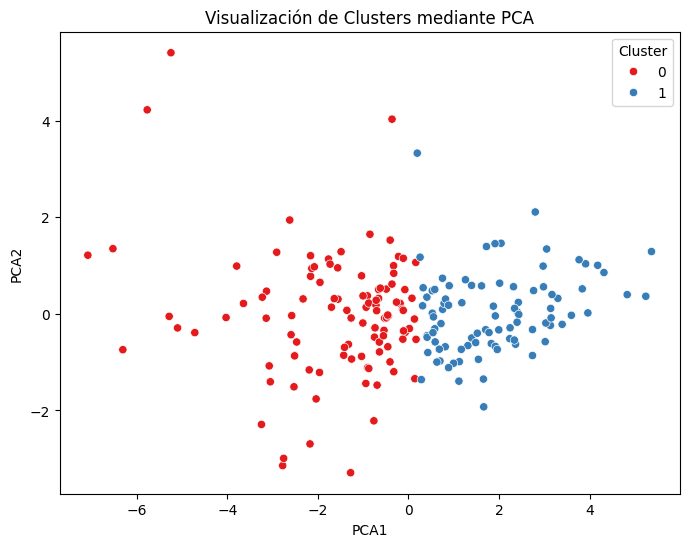

In [ ]:
# VISUALIZACIÓN PCA
# =====================================================

pca_vis = PCA(
    n_components=2
)

X_vis = pca_vis.fit_transform(
    X_scaled
)

df["PCA1"] = X_vis[:,0]
df["PCA2"] = X_vis[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1"
)

plt.title(
    "Visualización de Clusters mediante PCA"
)

plt.show()


## Visualización de los Clusters mediante UMAP

Como complemento a la visualización realizada con PCA, se utiliza UMAP para proyectar los datos académicos en un espacio bidimensional preservando mejor las relaciones locales entre los estudiantes. Esta técnica permite observar con mayor claridad la estructura de los clusters y evaluar visualmente el grado de separación y agrupamiento generado por el algoritmo K-Means.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


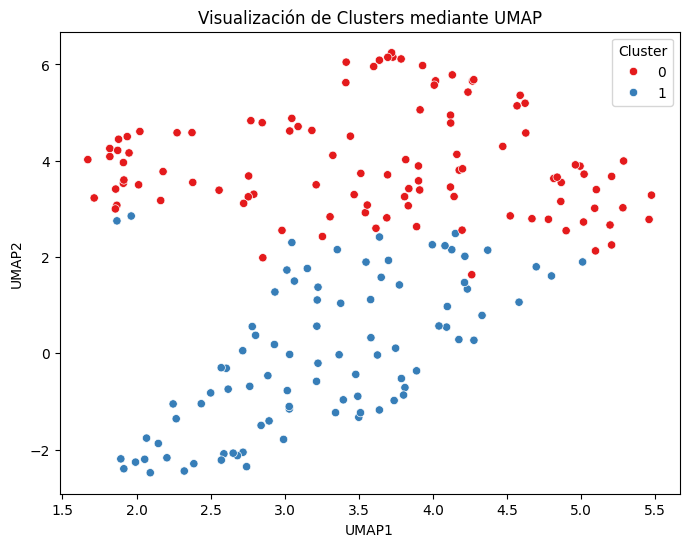


Proceso de clusterización finalizado correctamente.


In [ ]:
# VISUALIZACIÓN UMAP
# =====================================================

reductor = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = reductor.fit_transform(
    X_scaled
)

df["UMAP1"] = X_umap[:,0]
df["UMAP2"] = X_umap[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="Set1"
)

plt.title(
    "Visualización de Clusters mediante UMAP"
)

plt.show()

print(
    "\nProceso de clusterización finalizado correctamente."
)

# Conclusiones de la Clusterización

La aplicación de K-Means permitió identificar dos grupos de estudiantes con niveles de rendimiento académico diferenciados. El índice de Silhouette obtenido (0.2331) indica una separación moderada entre los clusters, lo que sugiere la existencia de patrones académicos distinguibles dentro de la población estudiantil.

La reducción de dimensionalidad mediante PCA conservó el 91.64% de la información original utilizando 9 componentes principales, permitiendo simplificar los datos sin perder información relevante para el análisis.

El estudio de los centroides mostró que el Cluster 1 presenta mejores calificaciones en todas las asignaturas respecto al Cluster 0, por lo que los grupos pueden interpretarse como estudiantes de rendimiento académico medio y rendimiento académico alto.

Finalmente, la distribución de las especialidades técnicas en ambos clusters evidencia que estudiantes de una misma técnica pueden pertenecer a diferentes grupos de rendimiento. Este resultado coincide con los análisis estadísticos previos y refuerza la conclusión de que la especialidad técnica tiene una influencia limitada sobre el desempeño académico de los estudiantes.